In [12]:
import pandas as pd
import numpy as np
import kagglehub

In [13]:
# Download latest version
path_str = kagglehub.dataset_download("andrewmvd/heart-failure-clinical-data")

print("Path to dataset files:", path_str)

csv_file_path = f"{path_str}/heart_failure_clinical_records_dataset.csv"

df = pd.read_csv(csv_file_path)

print("--- STEP 1: First 5 Rows ---")
display(df.head())

Using Colab cache for faster access to the 'heart-failure-clinical-data' dataset.
Path to dataset files: /kaggle/input/heart-failure-clinical-data
--- STEP 1: First 5 Rows ---


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [14]:
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values Count:")
print(df.isnull().sum())

Number of Rows: 299
Number of Columns: 13

Data Types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Missing Values Count:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


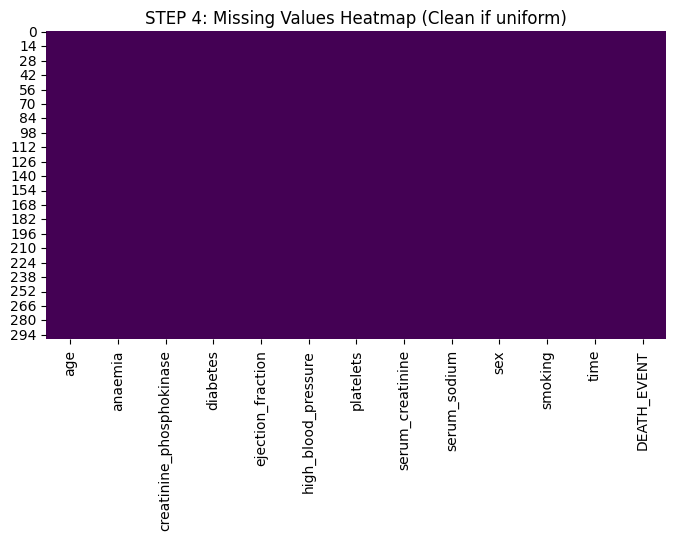

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("STEP 4: Missing Values Heatmap (Clean if uniform)")
plt.show()

In [16]:
# 1. Impute Missing Values (Step 6)
df = df.fillna(df.median(numeric_only=True))

# 2. Fix Inconsistencies (Step 8)
df = df[df['age'] > 0]

# 3. Remove Outliers using IQR for serum_creatinine (Step 7)
Q1 = df['serum_creatinine'].quantile(0.25)
Q3 = df['serum_creatinine'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Store original row count to compare
original_count = len(df)

# Filter dataset
df = df[(df['serum_creatinine'] >= lower_bound) & (df['serum_creatinine'] <= upper_bound)]

print(f"Original rows: {original_count}")
print(f"Rows after removing outliers: {len(df)}")
print(f"Removed {original_count - len(df)} outlier rows.")

Original rows: 299
Rows after removing outliers: 270
Removed 29 outlier rows.


In [17]:
# 1. Create age_group feature using pd.cut
bins = [0, 40, 60, 120]
labels = ['<40', '40-60', '>60']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

# 2. Create risk_score feature (Normalized product of ejection_fraction & serum_creatinine)
raw_risk = df['ejection_fraction'] * df['serum_creatinine']
df['risk_score'] = (raw_risk - raw_risk.min()) / (raw_risk.max() - raw_risk.min())

# Inspect the engineered features
print(df[['age', 'age_group', 'ejection_fraction', 'serum_creatinine', 'risk_score']].head())

    age age_group  ejection_fraction  serum_creatinine  risk_score
0  75.0       >60                 20               1.9    0.287245
1  55.0     40-60                 38               1.1    0.327974
2  65.0       >60                 20               1.3    0.158628
3  50.0     40-60                 20               1.9    0.287245
5  90.0       >60                 40               2.1    0.780279


In [18]:
from sklearn.preprocessing import MinMaxScaler

# 1. Encode Categorical Variables (Step 10)
# Convert 'age_group' into binary dummy variables
df = pd.get_dummies(df, columns=['age_group'], drop_first=True)

# 2. Normalize Numerical Features (Step 11)
scaler = MinMaxScaler()
cols_to_scale = ['age', 'platelets', 'serum_creatinine', 'ejection_fraction', 'serum_sodium']

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# Check scaled values sample
print("Scaled Numerical Features Sample:")
print(df[cols_to_scale].head())

Scaled Numerical Features Sample:
        age  platelets  serum_creatinine  ejection_fraction  serum_sodium
0  0.636364   0.290823             0.875           0.090909      0.485714
1  0.272727   0.288833             0.375           0.363636      0.657143
2  0.454545   0.165960             0.500           0.090909      0.457143
3  0.181818   0.224148             0.875           0.090909      0.685714
5  0.909091   0.216875             1.000           0.393939      0.542857


--- Cleaned Summary Statistics ---
                       mean    median       std
age                0.371605  0.363636  0.218401
platelets          0.291702  0.288833  0.118681
serum_creatinine   0.397616  0.375000  0.211494
ejection_fraction  0.367003  0.363636  0.178188
serum_sodium       0.682222  0.685714  0.119313


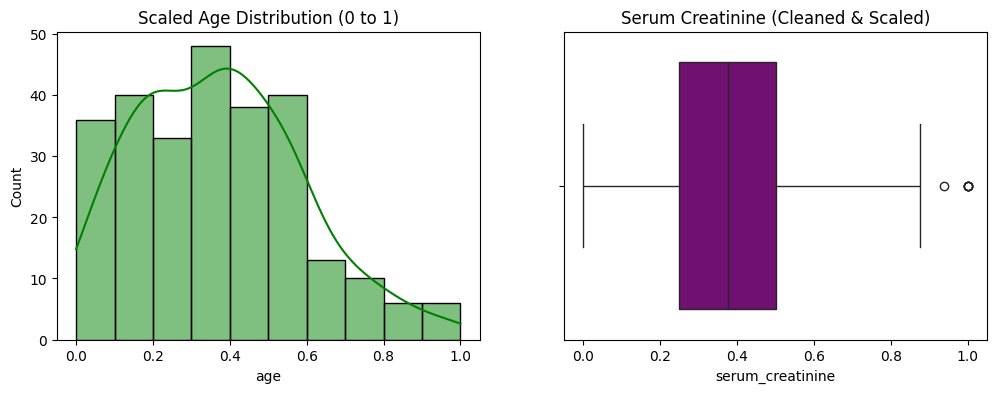


Total Missing Values Remaining: 0
Verification Passed: Dataset is completely clean and ready for ML training!


In [19]:
# 1. Compute Summary Statistics (Step 12)
print("--- Cleaned Summary Statistics ---")
stats = df[cols_to_scale].describe().T[['mean', '50%', 'std']]
stats.rename(columns={'50%': 'median'}, inplace=True)
print(stats)

# 2. Validate Cleaning with Visualizations (Step 13)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histplot of scaled age (should be bounded 0 to 1)
sns.histplot(df['age'], kde=True, ax=axes[0], color='green')
axes[0].set_title("Scaled Age Distribution (0 to 1)")

# Boxplot of serum_creatinine (outliers removed & scaled)
sns.boxplot(x=df['serum_creatinine'], ax=axes[1], color='purple')
axes[1].set_title("Serum Creatinine (Cleaned & Scaled)")

plt.show()

# 3. Check Final Missing Values (Step 14)
missing_count = df.isnull().sum().sum()
print(f"\nTotal Missing Values Remaining: {missing_count}")
if missing_count == 0:
    print("Verification Passed: Dataset is completely clean and ready for ML training!")